# Ten Internal Architectures for SILVA Points

A SILVA equilibrium point separates the solver from the architecture evaluated
inside each transition:

$$
z^\star
=
\Psi\!\left[
u + B_\theta(a(z^\star))
+ \sum_m I_{m,\theta}(a(z^\star),u,x,E,b)
\right].
$$

The internal architecture must return a field with the same shape as the
equilibrium state:

$$
B_\theta:\mathbb R^{\mathcal S}\rightarrow\mathbb R^{\mathcal S}.
$$

This notebook exercises ten compact reference architectures on vector, token,
and spatial states. It checks shape preservation, fixed-point execution,
residuals, and gradients. The checks are compatibility tests, not comparative
accuracy benchmarks.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[25]](https://jseluis.github.io/silva-networks/paper/references/#ref-25), [[26]](https://jseluis.github.io/silva-networks/paper/references/#ref-26), [[27]](https://jseluis.github.io/silva-networks/paper/references/#ref-27), [[28]](https://jseluis.github.io/silva-networks/paper/references/#ref-28), [[29]](https://jseluis.github.io/silva-networks/paper/references/#ref-29), [[30]](https://jseluis.github.io/silva-networks/paper/references/#ref-30), [[31]](https://jseluis.github.io/silva-networks/paper/references/#ref-31), [[32]](https://jseluis.github.io/silva-networks/paper/references/#ref-32), [[33]](https://jseluis.github.io/silva-networks/paper/references/#ref-33), [[34]](https://jseluis.github.io/silva-networks/paper/references/#ref-34). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from silva_networks import (
    GraphLocal,
    MeanFieldGlobal,
    SelfInteraction,
    SILVACortexLayer,
    SILVACortexNetwork,
    SolverConfig,
    TopKGlobalAttention,
    available_silva_point_architectures,
    silva_point_architecture,
    silva_point_architecture_info,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(140)

## Catalog and Tensor Contracts

The catalog is intentionally representative rather than ranked. Each entry
contributes a distinct computation pattern while preserving the state layout
needed by an equilibrium point.

In [3]:
for name in available_silva_point_architectures():
    info = silva_point_architecture_info(name)
    year = info.introduced if info.introduced is not None else "classic"
    print(f"{name:18s} | {info.state_layout:36s} | {year} | {info.summary}")

mlp                | (..., channels)                      | 1986 | Classic feed-forward channel mixing.
residual_mlp       | (..., channels)                      | 2015 | Residual channel-mixing blocks.
residual_cnn       | (batch, channels, height, width)     | 2015 | Residual local convolutional blocks.
unet               | (batch, channels, height, width)     | 2015 | Contracting and expanding paths with a skip connection.
dense_cnn          | (batch, channels, height, width)     | 2016 | Densely concatenated local convolutional features.
transformer        | (batch, tokens, channels)            | 2017 | Multi-head token attention and feed-forward mixing.
inverted_residual  | (batch, channels, height, width)     | 2018 | Expanded depthwise convolution with a narrow residual state.
fourier_operator   | (batch, channels, height, width)     | 2020 | Low-frequency spectral mixing plus a local projection.
mlp_mixer          | (batch, tokens, channels)            | 2021 | Alternating toke

## From the Implemented Transition to One Solver Update

The point first computes

$$
u=R_\phi(x),
\qquad h_k=a(z_k),
$$

then sums the architecture and interaction fields,

$$
q_k
=u+B_\theta(h_k)
+\sum_rH_{r,\theta}(h_k)
+\sum_sL_{s,\theta}(h_k,E)
+\sum_tG_{t,\theta}(h_k,b)
+\sum_vC_{v,\theta}(h_k,u,x,E,b).
$$

The undamped transition and damped Picard update are

$$
F_\theta(z_k,u)=\mathcal N\!\left[\Psi(O_\theta(q_k))\right],
$$

$$
z_{k+1}=(1-\alpha)z_k+\alpha F_\theta(z_k,u).
$$

The next cell reconstructs this order manually for one MLP point and checks it
against `SILVACortexLayer.f`.

In [4]:
manual_architecture = silva_point_architecture(
    "mlp",
    dim=4,
    hidden_dim=6,
    depth=1,
    scale=0.08,
)
manual_point = SILVACortexLayer(
    input_encoder=torch.nn.Identity(),
    state_network=manual_architecture,
    normalize=False,
    activation=torch.tanh,
    output_activation=torch.tanh,
    config=SolverConfig(solver="picard", max_iter=1, alpha=0.3),
)
manual_input = torch.randn(2, 4)
stimulus = manual_point.encode(manual_input)
z0 = manual_point.initial_state(stimulus)
activated = torch.tanh(z0)
architecture_field = manual_architecture(activated)
manual_undamped = torch.tanh(stimulus + architecture_field)
package_undamped = manual_point.f(z0, stimulus, x=manual_input)
manual_damped = 0.7 * z0 + 0.3 * manual_undamped

assert torch.allclose(manual_undamped, package_undamped)
print("stimulus:", tuple(stimulus.shape))
print("architecture field:", tuple(architecture_field.shape))
print("undamped transition:", tuple(package_undamped.shape))
print("one damped update norm:", f"{float(torch.linalg.vector_norm(manual_damped)):.3e}")

stimulus: (2, 4)
architecture field: (2, 4)
undamped transition: (2, 4)
one damped update norm: 4.636e-01


## Architecture Scale, Damping, and the Jacobian

For a catalog field $B_{\theta,s}=s\widetilde B_\theta$ and damped update
$T_\alpha=(1-\alpha)I+\alpha F$, differentiation gives

$$
J_{B_{\theta,s}}=sJ_{\widetilde B_\theta},
\qquad
J_{T_\alpha}=(1-\alpha)I+\alpha J_F.
$$

On a tiny four-dimensional state, the complete matrices can be formed directly.
For practical states, use matrix-free Jacobian-vector products instead.

In [5]:
tiny_state = torch.zeros(1, 4, requires_grad=True)
tiny_stimulus = manual_point.encode(manual_input[:1]).detach()
jacobian_f = torch.autograd.functional.jacobian(
    lambda value: manual_point.f(value, tiny_stimulus).reshape(-1),
    tiny_state,
).reshape(4, 4)
identity = torch.eye(4)

for alpha in (0.15, 0.30, 0.60):
    jacobian_damped = (1.0 - alpha) * identity + alpha * jacobian_f
    spectral_radius = torch.linalg.eigvals(jacobian_damped).abs().max()
    print(
        f"alpha={alpha:.2f} "
        f"||J_T||_2={float(torch.linalg.matrix_norm(jacobian_damped, ord=2)):.3f} "
        f"rho(J_T)={float(spectral_radius):.3f}"
    )

alpha=0.15 ||J_T||_2=0.852 rho(J_T)=0.851
alpha=0.30 ||J_T||_2=0.703 rho(J_T)=0.702
alpha=0.60 ||J_T||_2=0.406 rho(J_T)=0.403


In [6]:
SPECS = {
    "mlp": ((4, 8), {"dim": 8, "hidden_dim": 12}),
    "residual_mlp": ((4, 8), {"dim": 8, "hidden_dim": 12}),
    "residual_cnn": ((3, 4, 8, 8), {"channels": 4, "depth": 1}),
    "unet": ((3, 4, 8, 8), {"channels": 4, "base_channels": 6}),
    "dense_cnn": ((3, 4, 8, 8), {"channels": 4, "growth_rate": 3, "depth": 2}),
    "transformer": ((3, 6, 8), {"dim": 8, "heads": 2, "hidden_dim": 12}),
    "inverted_residual": ((3, 4, 8, 8), {"channels": 4, "expansion": 2}),
    "fourier_operator": (
        (3, 4, 8, 8),
        {"channels": 4, "modes_height": 3, "modes_width": 3},
    ),
    "mlp_mixer": ((3, 6, 8), {"tokens": 6, "dim": 8}),
    "convnext_v2": ((3, 4, 8, 8), {"channels": 4, "expansion": 2}),
}


def check_architecture(name):
    shape, kwargs = SPECS[name]
    architecture = silva_point_architecture(name, **kwargs)
    stimulus = torch.randn(*shape, requires_grad=True)
    point = SILVACortexLayer(
        input_encoder=torch.nn.Identity(),
        state_network=architecture,
        normalize=False,
        config=SolverConfig(solver="picard", max_iter=2, alpha=0.25),
    )
    result = point(stimulus, return_result=True)
    loss = result.z.square().mean()
    loss.backward()
    gradient_norm = math.sqrt(
        sum(
            float(parameter.grad.square().sum())
            for parameter in architecture.parameters()
            if parameter.grad is not None
        )
    )
    assert result.z.shape == stimulus.shape
    assert torch.isfinite(result.z).all()
    assert gradient_norm > 0.0
    return {
        "name": name,
        "parameters": sum(parameter.numel() for parameter in architecture.parameters()),
        "start": float(result.residuals[0]),
        "end": float(result.residuals[-1]),
        "gradient_norm": gradient_norm,
    }

## Vector-State Architectures

MLP and residual-MLP fields act on the final channel dimension. For hidden
width $M$ and GELU $\phi$, the MLP computes

$$
h_1=\phi(W_0z+b_0),
\qquad
h_{j+1}=\phi(W_jh_j+b_j),
\qquad
B_\theta(z)=s(W_oh_d+b_o).
$$

One pre-normalized residual-MLP block computes

$$
h_{j+1}
=h_j+W_{j,2}\phi\!\left(W_{j,1}\operatorname{LN}(h_j)+b_{j,1}\right)+b_{j,2},
\qquad
B_\theta(z)=s h_d.
$$

Both support `(batch, channels)` and can act independently at every token when
leading dimensions are retained. The internal residual path is distinct from
the recurrence created by the equilibrium solver.

In [7]:
vector_results = [check_architecture(name) for name in ("mlp", "residual_mlp")]
vector_results

[{'name': 'mlp',
  'parameters': 368,
  'start': 3.486447334289551,
  'end': 2.6149888038635254,
  'gradient_norm': 0.0013763749073824206},
 {'name': 'residual_mlp',
  'parameters': 456,
  'start': 3.430180072784424,
  'end': 2.608652353286743,
  'gradient_norm': 0.005575150072881444}]

## Token-State Architectures

The Transformer and MLP-Mixer entries use `(batch, tokens, channels)` states.
For one attention head,

$$
A(z)
=\operatorname{softmax}\!\left(
\frac{(zW_Q)(zW_K)^{\mathsf T}}{\sqrt{D_h}}
\right)zW_V.
$$

The Transformer combines pre-normalized attention and a channel feed-forward
block. MLP-Mixer instead alternates a token MLP and channel MLP:

$$
u=z+[\operatorname{MLP}_{\mathrm{token}}(\operatorname{LN}(z)^{\mathsf T})]^{\mathsf T},
$$

$$
B_\theta(z)
=s\left[u+\operatorname{MLP}_{\mathrm{channel}}(\operatorname{LN}(u))\right].
$$

Attention can construct weights for a variable token count. Mixer fixes token
count when its token-mixing matrices are constructed.

In [8]:
token_results = [check_architecture(name) for name in ("transformer", "mlp_mixer")]
token_results

[{'name': 'transformer',
  'parameters': 532,
  'start': 7.222772598266602,
  'end': 5.507390022277832,
  'gradient_norm': 0.01904106426558271},
 {'name': 'mlp_mixer',
  'parameters': 474,
  'start': 7.629364967346191,
  'end': 5.779966354370117,
  'gradient_norm': 0.002766453962616126}]

## Spatial-State Architectures

The six spatial entries use `(batch, channels, height, width)` states.

- Residual CNN applies normalized local convolutions and adds each update to its
  block input.
- U-Net constructs a skip field, downsamples to a bottleneck, upsamples, joins
  the skip and expanded fields, and restores the original shape.
- Dense CNN concatenates every preceding feature field and projects the final
  concatenation back to the state channels.
- Inverted residual expands channels, applies a depthwise convolution, projects
  back, and adds the narrow identity path.
- Fourier operator learns complex channel mixing on retained frequencies and
  adds a pointwise spatial projection.
- ConvNeXt V2 combines a depthwise $7\times7$ convolution, channel expansion,
  global response normalization, projection, and residual path.

All temporary widths and resolutions must be removed before the field returns
to the equilibrium point.

For the residual CNN,

$$
v_j=K_{j,1}*\phi(\operatorname{GN}_1(h_j)),
\qquad
h_{j+1}=h_j+K_{j,2}*\phi(\operatorname{GN}_2(v_j)).
$$

For dense convolution with growth features $d_j$,

$$
d_j=K_j*\phi\!\left(\operatorname{GN}[z\Vert d_1\Vert\cdots\Vert d_{j-1}]\right),
$$

$$
B_\theta(z)=sP[z\Vert d_1\Vert\cdots\Vert d_d].
$$

For the inverted residual field,

$$
p=\phi(P_\uparrow z),
\qquad
d=\phi(\operatorname{GN}(K_{\mathrm{dw}}*p)),
\qquad
B_\theta(z)=s(z+P_\downarrow d).
$$

For ConvNeXt V2, let $p$ be the expanded channel-last field after depthwise
convolution and GELU. Global response normalization uses

$$
g_c=\|p_{:,:,c}\|_2,
\qquad
n_c=\frac{g_c}{\operatorname{mean}_j(g_j)+\varepsilon},
$$

$$
\operatorname{GRN}(p)_c=p_c+\gamma_cn_cp_c+\beta_c,
\qquad
B_\theta(z)=s\left[z+P_\downarrow\operatorname{GRN}(p)\right].
$$

In [9]:
spatial_names = (
    "residual_cnn",
    "unet",
    "dense_cnn",
    "inverted_residual",
    "fourier_operator",
    "convnext_v2",
)
spatial_results = [check_architecture(name) for name in spatial_names]
spatial_results

[{'name': 'residual_cnn',
  'parameters': 312,
  'start': 17.202537536621094,
  'end': 13.111798286437988,
  'gradient_norm': 0.003000237507629047},
 {'name': 'unet',
  'parameters': 1758,
  'start': 16.857593536376953,
  'end': 12.635930061340332,
  'gradient_norm': 0.0006761374513004551},
 {'name': 'dense_cnn',
  'parameters': 369,
  'start': 17.25940704345703,
  'end': 12.967610359191895,
  'gradient_norm': 0.0011428069926958941},
 {'name': 'inverted_residual',
  'parameters': 172,
  'start': 17.523311614990234,
  'end': 13.297492027282715,
  'gradient_norm': 0.001974460403064542},
 {'name': 'fourier_operator',
  'parameters': 596,
  'start': 17.453336715698242,
  'end': 13.085836410522461,
  'gradient_norm': 0.0007694457033083897},
 {'name': 'convnext_v2',
  'parameters': 300,
  'start': 17.385408401489258,
  'end': 13.197778701782227,
  'gradient_norm': 0.0008416800311797783}]

### Trace the U-Net Shape Derivation

For skip field $e$, bottleneck $\ell$, and expanded field $v$,

$$
e=R_C(z),
\qquad
\ell=R_{C_b}(\phi(K_\downarrow*e)),
\qquad
v=K_\uparrow^{\mathsf T}*\ell,
$$

$$
B_\theta(z)
=sK_{d,2}*\phi(K_{d,1}*[e\Vert v]).
$$

The implementation interpolates $v$ to the skip size when odd input dimensions
prevent an exact transposed-convolution recovery. Forward hooks reveal the real
intermediate tensors.

In [10]:
unet = silva_point_architecture("unet", channels=4, base_channels=8)
unet_shapes = {}


def record_shape(name):
    def hook(_module, _inputs, output):
        unet_shapes[name] = tuple(output.shape)
    return hook


handles = [
    unet.encoder.register_forward_hook(record_shape("skip")),
    unet.down.register_forward_hook(record_shape("down")),
    unet.bottleneck.register_forward_hook(record_shape("bottleneck")),
    unet.up.register_forward_hook(record_shape("up before resize")),
    unet.decoder.register_forward_hook(record_shape("decoded")),
]
odd_state = torch.randn(2, 4, 15, 13)
odd_field = unet(odd_state)
for handle in handles:
    handle.remove()

print("input:", tuple(odd_state.shape))
for name, shape in unet_shapes.items():
    print(f"{name:16s}", shape)
print("returned field:", tuple(odd_field.shape))
assert odd_field.shape == odd_state.shape

input: (2, 4, 15, 13)
skip             (2, 4, 15, 13)
down             (2, 8, 8, 7)
bottleneck       (2, 8, 8, 7)
up before resize (2, 4, 16, 14)
decoded          (2, 4, 15, 13)
returned field: (2, 4, 15, 13)


### Derive the Fourier Field from Its Two Branches

For retained modes $k\in\mathcal K$,

$$
\widehat v_o(k)=\sum_iW_{oi}(k)\widehat z_i(k),
\qquad
B_\theta(z)=s\left(\mathcal F_h^{-1}\widehat v+Pz\right).
$$

The spectral branch communicates across the grid. The $1\times1$ projection
$P$ mixes channels locally. The code below verifies the exact sum and then
reuses the same learned weights on three spatial resolutions.

In [11]:
fourier = silva_point_architecture(
    "fourier_operator",
    channels=4,
    modes_height=3,
    modes_width=3,
    scale=0.05,
)
fourier_probe = torch.randn(2, 4, 12, 10)
spectral_field = fourier.spectral(fourier_probe)
local_field = fourier.local(fourier_probe)
combined_field = fourier(fourier_probe)
assert torch.allclose(combined_field, fourier.scale * (spectral_field + local_field))

print("complex weight storage:", tuple(fourier.spectral.weight_top.shape))
for height, width in ((12, 10), (18, 14), (24, 20)):
    grid = torch.randn(1, 4, height, width)
    field = fourier(grid)
    assert field.shape == grid.shape
    print(f"{height:2d} x {width:2d} -> {tuple(field.shape)}")

complex weight storage: (4, 4, 3, 3, 2)
12 x 10 -> (1, 4, 12, 10)
18 x 14 -> (1, 4, 18, 14)
24 x 20 -> (1, 4, 24, 20)


## Compact Validation Summary

For a two-step damped solve, the final residual should be finite and lower than
the first-step residual. A nonzero gradient confirms that the selected module
participates in the differentiable transition.

In [12]:
results = vector_results + token_results + spatial_results
for row in results:
    ratio = row["end"] / row["start"]
    assert math.isfinite(ratio) and ratio < 1.0
    print(
        f"{row['name']:18s} parameters={row['parameters']:5d} "
        f"residual ratio={ratio:.3f} gradient={row['gradient_norm']:.3e}"
    )

mlp                parameters=  368 residual ratio=0.750 gradient=1.376e-03
residual_mlp       parameters=  456 residual ratio=0.761 gradient=5.575e-03
transformer        parameters=  532 residual ratio=0.763 gradient=1.904e-02
mlp_mixer          parameters=  474 residual ratio=0.758 gradient=2.766e-03
residual_cnn       parameters=  312 residual ratio=0.762 gradient=3.000e-03
unet               parameters= 1758 residual ratio=0.750 gradient=6.761e-04
dense_cnn          parameters=  369 residual ratio=0.751 gradient=1.143e-03
inverted_residual  parameters=  172 residual ratio=0.759 gradient=1.974e-03
fourier_operator   parameters=  596 residual ratio=0.750 gradient=7.694e-04
convnext_v2        parameters=  300 residual ratio=0.759 gradient=8.417e-04


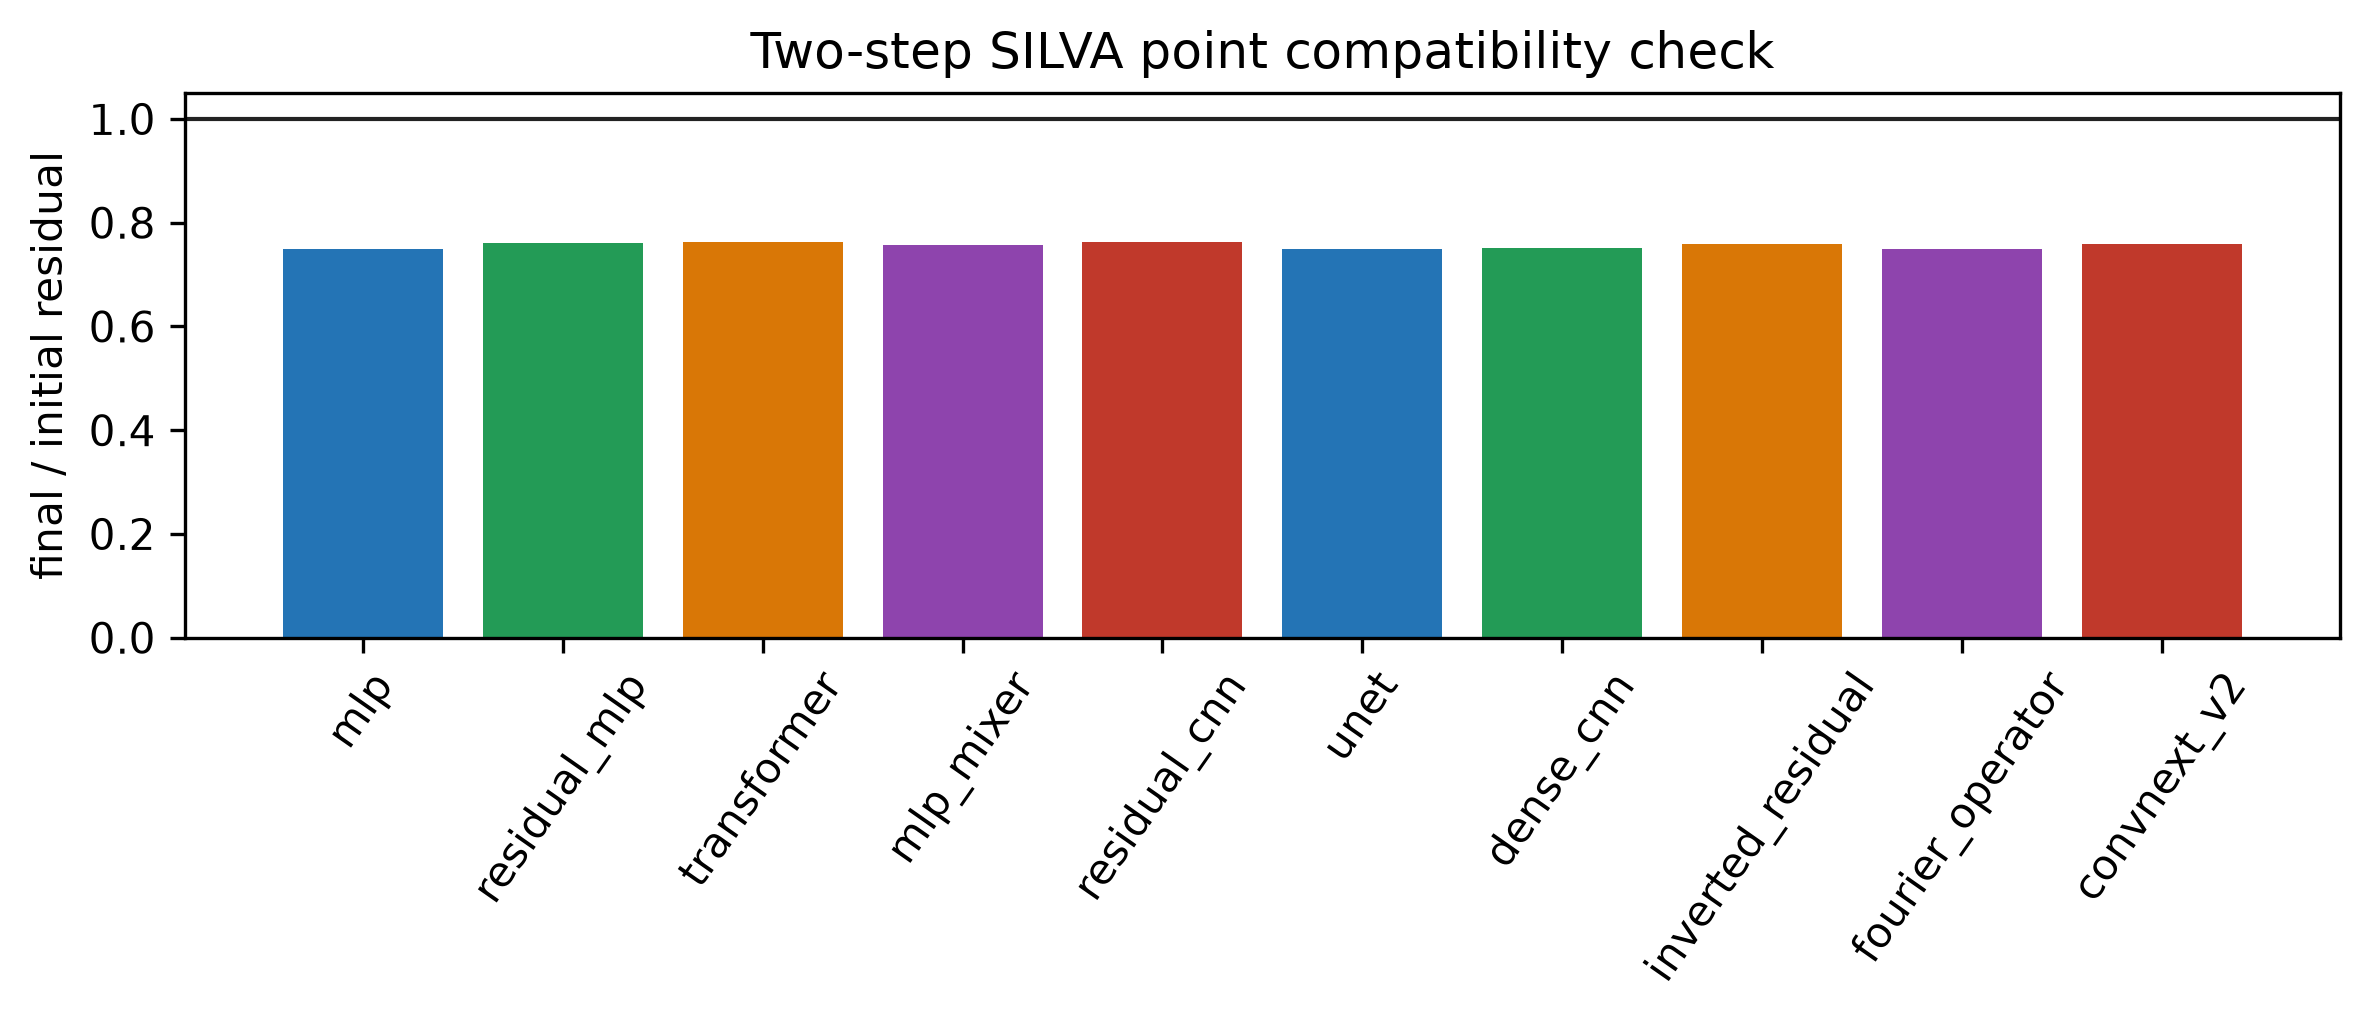

In [13]:
names = [row["name"] for row in results]
ratios = [row["end"] / row["start"] for row in results]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(names, ratios, color=["#2474b5", "#239b56", "#d97706", "#8e44ad", "#c0392b"] * 2)
ax.axhline(1.0, color="#222222", linewidth=1)
ax.set_ylabel("final / initial residual")
ax.set_title("Two-step SILVA point compatibility check")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()

## One Fully Populated SILVA Point

The next point uses every configurable operator slot:

$$
q
=u+B_2(B_1(h))+H(h)+L(h,E)
+G_{\mathrm{mean}}(h,b)+G_{\mathrm{attn}}(h,b)+C(h,u),
$$

$$
F(z)=\operatorname{LN}\!\left[\tanh(O(q))\right].
$$

The state is `(entities, channels)`. `edge_index` defines local graph messages,
and `batch` keeps global aggregation inside each graph. The custom stimulus gate
shows how a module requests only the context it needs by naming `stimulus` in
its `forward` signature.

In [14]:
class StimulusGate(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = torch.nn.Linear(dim, dim)

    def forward(self, z, stimulus):
        return torch.sigmoid(self.gate(stimulus)) * z


full_point = SILVACortexLayer(
    input_dim=5,
    state_dim=8,
    state_network=[
        silva_point_architecture(
            "residual_mlp", dim=8, hidden_dim=16, depth=2, scale=0.05
        ),
        silva_point_architecture("mlp", dim=8, hidden_dim=12, depth=1, scale=0.05),
    ],
    self_terms=SelfInteraction(8),
    local_terms=GraphLocal(8),
    global_terms=[MeanFieldGlobal(8), TopKGlobalAttention(8, k=3)],
    interaction_terms=StimulusGate(8),
    output_network=torch.nn.Linear(8, 8),
    normalizer=torch.nn.LayerNorm(8),
    activation=F.silu,
    output_activation=torch.tanh,
    initializer="stimulus",
    config=SolverConfig(
        solver="anderson",
        max_iter=5,
        tol=1e-5,
        alpha=0.2,
        history=3,
        anderson_batch_dims=0,
    ),
)

graph_x = torch.randn(8, 5)
graph_edges = torch.tensor(
    [
        [0, 1, 2, 3, 4, 5, 6, 7],
        [1, 2, 3, 0, 5, 6, 7, 4],
    ]
)
graph_batch = torch.tensor([0, 0, 0, 0, 1, 1, 1, 1])
full_result = full_point(
    graph_x,
    edge_index=graph_edges,
    batch=graph_batch,
    return_result=True,
)
full_loss = full_result.z.square().mean()
full_loss.backward()

gradient_checks = {
    "encoder": full_point.input_encoder.weight.grad,
    "internal": full_point.state_network[0].blocks[0].network[0].weight.grad,
    "self": full_point.self_terms[0].proj.weight.grad,
    "local": full_point.local_terms[0].proj.weight.grad,
    "mean global": full_point.global_terms[0].proj.weight.grad,
    "attention global": full_point.global_terms[1].W_q.weight.grad,
    "custom": full_point.interaction_terms[0].gate.weight.grad,
    "output": full_point.output_network.weight.grad,
    "normalizer": full_point.normalizer.weight.grad,
}
assert all(gradient is not None for gradient in gradient_checks.values())
print("state:", tuple(full_result.z.shape))
print("residuals:", [f"{value:.3e}" for value in full_result.residuals])
print("gradient slots:", ", ".join(gradient_checks))

state: (8, 8)
residuals: ['1.008e+01', '7.953e+00', '6.058e+00', '5.338e+00', '3.643e+00']
gradient slots: encoder, internal, self, local, mean global, attention global, custom, output, normalizer


## Several Architectures Inside One Point

`state_network` may be a sequence. The modules are evaluated in order during
every solver step, so each module must preserve the shared state shape:

$$
B_\theta
=
B_{\theta,3}\circ B_{\theta,2}\circ B_{\theta,1}.
$$

In [15]:
composed_point = SILVACortexLayer(
    input_encoder=torch.nn.Identity(),
    state_network=[
        silva_point_architecture("residual_cnn", channels=4, depth=1),
        silva_point_architecture("convnext_v2", channels=4, expansion=2),
        silva_point_architecture("unet", channels=4, base_channels=6),
    ],
    normalizer=torch.nn.GroupNorm(1, 4),
    config=SolverConfig(solver="picard", max_iter=3, alpha=0.25),
)
composed_result = composed_point(torch.randn(3, 4, 8, 8), return_result=True)
print("composed state:", tuple(composed_result.z.shape))
print("residuals:", [f"{value:.3e}" for value in composed_result.residuals])

composed state: (3, 4, 8, 8)
residuals: ['2.771e+01', '2.078e+01', '1.559e+01']


## Different Architectures Across Linked Points

The next model links two equilibrium points. The first uses a residual CNN with
Picard iteration; the second uses U-Net with Anderson acceleration. A tiny bar
dataset checks the complete forward and backward path.

In [16]:
def make_bar_data(samples=12, size=8):
    generator = torch.Generator().manual_seed(141)
    images = 0.04 * torch.randn(samples, 4, size, size, generator=generator)
    labels = torch.arange(samples) % 2
    for index, label in enumerate(labels):
        if int(label) == 0:
            images[index, :, :, 3:5] += 1.0
        else:
            images[index, :, 3:5, :] += 1.0
    return images, labels


network = SILVACortexNetwork(
    [
        SILVACortexLayer(
            input_encoder=torch.nn.Identity(),
            state_network=silva_point_architecture("residual_cnn", channels=4, depth=2),
            normalizer=torch.nn.GroupNorm(1, 4),
            config=SolverConfig(solver="picard", max_iter=3, alpha=0.35),
        ),
        SILVACortexLayer(
            input_encoder=torch.nn.Identity(),
            state_network=silva_point_architecture("unet", channels=4, base_channels=8),
            normalizer=torch.nn.GroupNorm(1, 4),
            config=SolverConfig(solver="anderson", max_iter=3, alpha=0.2, history=2),
        ),
    ],
    links="tanh",
    head=torch.nn.Sequential(
        torch.nn.AdaptiveAvgPool2d(1),
        torch.nn.Flatten(),
        torch.nn.Linear(4, 2),
    ),
)

images, labels = make_bar_data()
network_result = network(images, return_results=True)
loss = F.cross_entropy(network_result.output, labels)
loss.backward()

print("logits:", tuple(network_result.output.shape))
print("states:", [tuple(state.shape) for state in network_result.states])
print("solvers:", [result.solver for result in network_result.solver_results])
print("loss:", f"{float(loss):.4f}")
print(
    "first point gradient:",
    network.layers[0].state_network[0].blocks[0].conv1.weight.grad is not None,
)

logits: (12, 2)
states: [(12, 4, 8, 8), (12, 4, 8, 8)]
solvers: ['picard', 'anderson']
loss: 0.7065
first point gradient: True


## Multiple Architectures Inside Every Linked Point

Internal depth and equilibrium depth can be combined. The first point below
contains a residual CNN and U-Net. A shape-changing link pools its solved
spatial state to a vector. The second point then contains a residual MLP and
plain MLP:

$$
x
\xrightarrow{\;B_{1,2}\circ B_{1,1}\;}
z_1^\star\in\mathbb R^{4\times H\times W}
\xrightarrow{\;P\;}
\mathbb R^4
\xrightarrow{\;B_{2,2}\circ B_{2,1}\;}
z_2^\star\in\mathbb R^8.
$$

Each point has its own state contract and solver. Only modules inside the same
`state_network` sequence must share a point boundary shape.

In [17]:
spatial_to_vector = torch.nn.Sequential(
    torch.nn.AdaptiveAvgPool2d(1),
    torch.nn.Flatten(),
)

heterogeneous_network = SILVACortexNetwork(
    [
        SILVACortexLayer(
            input_encoder=torch.nn.Identity(),
            state_network=[
                silva_point_architecture("residual_cnn", channels=4, depth=1),
                silva_point_architecture("unet", channels=4, base_channels=6),
            ],
            normalizer=torch.nn.GroupNorm(1, 4),
            config=SolverConfig(solver="picard", max_iter=3, alpha=0.3),
        ),
        SILVACortexLayer(
            input_encoder=torch.nn.Linear(4, 8),
            state_dim=8,
            state_network=[
                silva_point_architecture("residual_mlp", dim=8, hidden_dim=12, depth=2),
                silva_point_architecture("mlp", dim=8, hidden_dim=12, depth=1),
            ],
            config=SolverConfig(
                solver="anderson",
                max_iter=4,
                alpha=0.2,
                history=2,
                anderson_batch_dims=1,
            ),
        ),
    ],
    links=spatial_to_vector,
    head=torch.nn.Linear(8, 2),
)

heterogeneous_result = heterogeneous_network(images, return_results=True)
heterogeneous_loss = F.cross_entropy(heterogeneous_result.output, labels)
heterogeneous_loss.backward()

print("point states:", [tuple(state.shape) for state in heterogeneous_result.states])
print("logits:", tuple(heterogeneous_result.output.shape))
print("solvers:", [item.solver for item in heterogeneous_result.solver_results])
assert heterogeneous_result.states[0].shape == (12, 4, 8, 8)
assert heterogeneous_result.states[1].shape == (12, 8)

point states: [(12, 4, 8, 8), (12, 8)]
logits: (12, 2)
solvers: ['picard', 'anderson']


## Train a Tiny End-to-End Task

The next loop trains the heterogeneous network on the deterministic bar data.
This verifies more than a single backward call: both equilibrium points, the
shape-changing link, and the readout remain connected through repeated updates.
The tiny task is a software and learning-path check, not a benchmark.

In [18]:
torch.manual_seed(142)
training_network = SILVACortexNetwork(
    [
        SILVACortexLayer(
            input_encoder=torch.nn.Identity(),
            state_network=[
                silva_point_architecture("residual_cnn", channels=4, depth=1, scale=0.05),
                silva_point_architecture("unet", channels=4, base_channels=6, scale=0.05),
            ],
            normalize=False,
            config=SolverConfig(solver="picard", max_iter=2, alpha=0.3),
        ),
        SILVACortexLayer(
            input_encoder=torch.nn.Linear(4, 8),
            state_dim=8,
            state_network=[
                silva_point_architecture("residual_mlp", dim=8, hidden_dim=12, depth=1),
                silva_point_architecture("mlp", dim=8, hidden_dim=12, depth=1),
            ],
            normalize=False,
            config=SolverConfig(solver="picard", max_iter=2, alpha=0.25),
        ),
    ],
    links=spatial_to_vector,
    head=torch.nn.Linear(8, 2),
)
optimizer = torch.optim.Adam(training_network.parameters(), lr=2e-2)
training_losses = []

for step in range(10):
    optimizer.zero_grad()
    logits = training_network(images)
    step_loss = F.cross_entropy(logits, labels)
    step_loss.backward()
    optimizer.step()
    training_losses.append(float(step_loss.detach()))

print("initial loss:", f"{training_losses[0]:.4f}")
print("final loss:", f"{training_losses[-1]:.4f}")
assert training_losses[-1] < training_losses[0]

initial loss: 0.7007
final loss: 0.6459


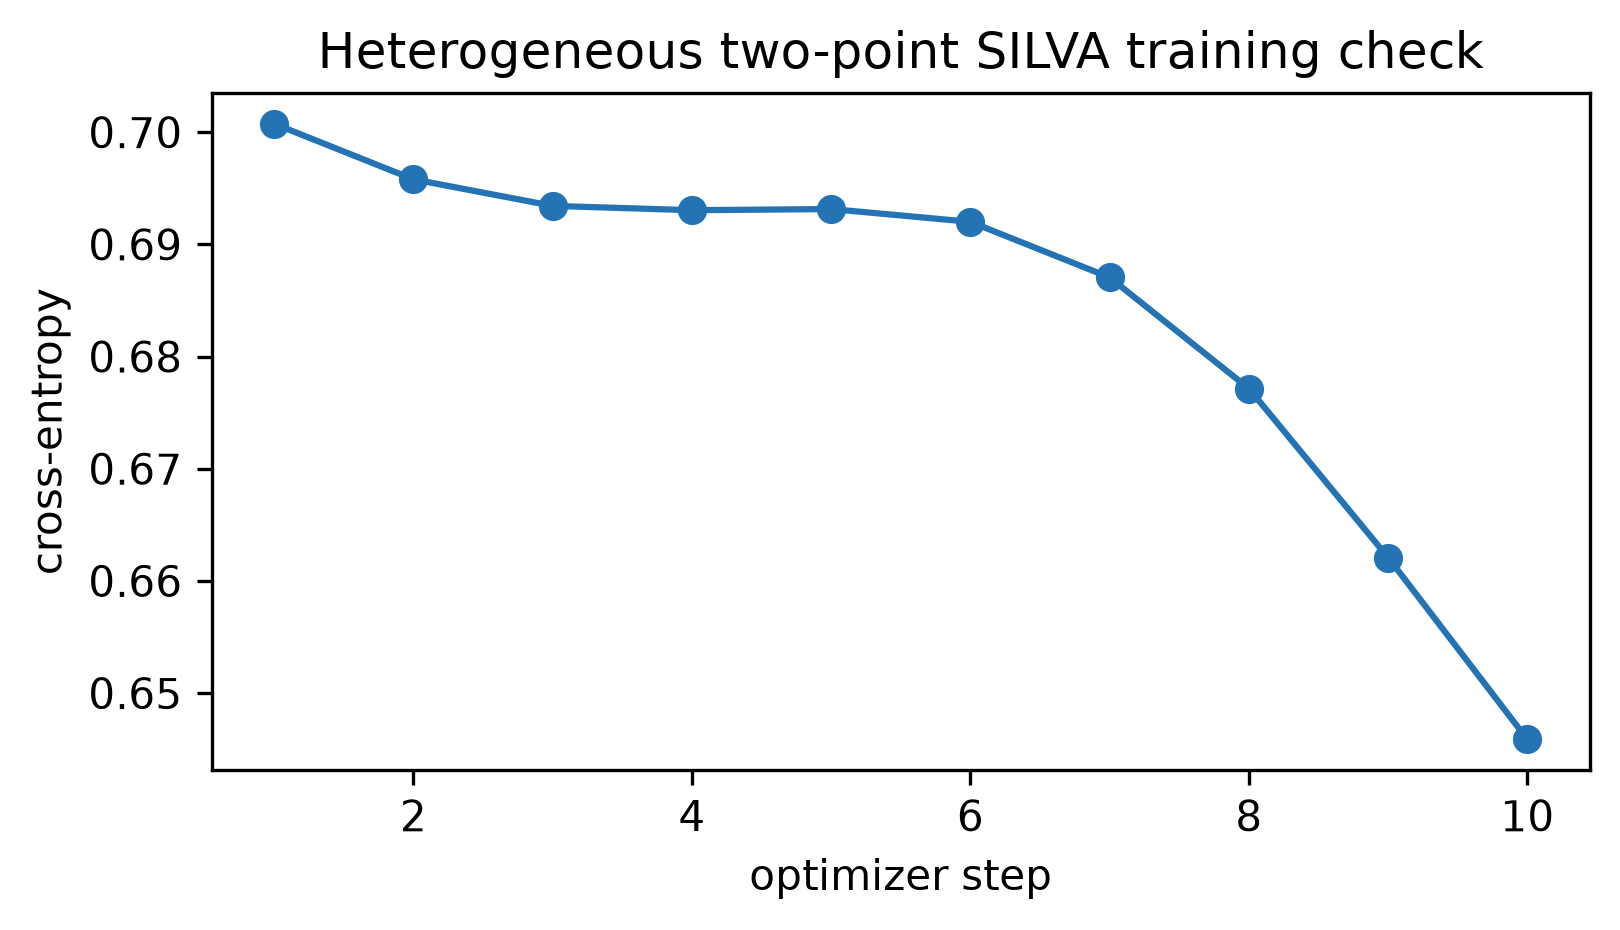

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(range(1, len(training_losses) + 1), training_losses, marker="o", color="#2474b5")
ax.set_xlabel("optimizer step")
ax.set_ylabel("cross-entropy")
ax.set_title("Heterogeneous two-point SILVA training check")
fig.tight_layout()

## Selection Rules

- Use vector MLPs for tabular or pooled feature states.
- Use Transformer when token interactions should depend on content.
- Use MLP-Mixer when token count is fixed and attention is unnecessary.
- Use residual, dense, inverted-residual, or ConvNeXt V2 blocks for local image structure.
- Use U-Net when one equilibrium evaluation needs multiple spatial scales.
- Use the Fourier operator when global spectral modes are part of the modeling assumption.
- Keep every module shape-preserving at the point boundary and tune solver damping after changing the internal architecture.

Primary sources: [multilayer back-propagation](https://doi.org/10.1038/323533a0),
[ResNet](https://arxiv.org/abs/1512.03385),
[U-Net](https://arxiv.org/abs/1505.04597),
[DenseNet](https://arxiv.org/abs/1608.06993),
[Transformer](https://arxiv.org/abs/1706.03762),
[MobileNetV2](https://arxiv.org/abs/1801.04381),
[Fourier Neural Operator](https://arxiv.org/abs/2010.08895),
[MLP-Mixer](https://arxiv.org/abs/2105.01601), and
[ConvNeXt V2](https://arxiv.org/abs/2301.00808).

## From 14 Point Architecture Catalog to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | one image tensor per resolution or linked SILVA point |
| Condition | image features and per-scale source injections |
| Repeated computation | shape-preserving convolutional, U-Net, attention, or multiscale fusion blocks |
| Required invariants | channel/spatial shape at every scale and deterministic fusion |
| Replaceable components | stem, per-scale injections, transition blocks, links, task head, and solvers |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Define Every Operator Inside One Point

```python
point = SILVACortexLayer(
    state_dim=channels,
    input_encoder=my_source,
    state_network=[my_unet, my_spectral_block],
    self_terms=[my_self_field],
    local_terms=[my_graph_or_convolution],
    global_terms=[my_global_context],
    interaction_terms=[my_known_physics],
    output_network=my_transition_head,
    normalizer=my_normalizer,
    normalize=False,
    config=solver_config,
)
```

Modules in `state_network` are sequential. Branch lists are independent fields
summed into the completed transition.


In [20]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**task error, per-scale residuals, and gradient agreement**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **image resolution, channels, scales, internal depth, and batch size**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [21]:
notebook_reproduction_record = {
    "notebook": '14_point_architecture_catalog.ipynb',
    "state": 'one image tensor per resolution or linked SILVA point',
    "condition": 'image features and per-scale source injections',
    "transition": 'shape-preserving convolutional, U-Net, attention, or multiscale fusion blocks',
    "invariants": 'channel/spatial shape at every scale and deterministic fusion',
    "compact_metric": 'task error, per-scale residuals, and gradient agreement',
    "scale_axis": 'image resolution, channels, scales, internal depth, and batch size',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '14_point_architecture_catalog.ipynb',
 'state': 'one image tensor per resolution or linked SILVA point',
 'condition': 'image features and per-scale source injections',
 'transition': 'shape-preserving convolutional, U-Net, attention, or multiscale fusion blocks',
 'invariants': 'channel/spatial shape at every scale and deterministic fusion',
 'compact_metric': 'task error, per-scale residuals, and gradient agreement',
 'scale_axis': 'image resolution, channels, scales, internal depth, and batch size'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **spatial feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **one image tensor per resolution or linked SILVA point**, and its repeated map,
**shape-preserving convolutional, U-Net, attention, or multiscale fusion blocks**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [22]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('spatial feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


spatial feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


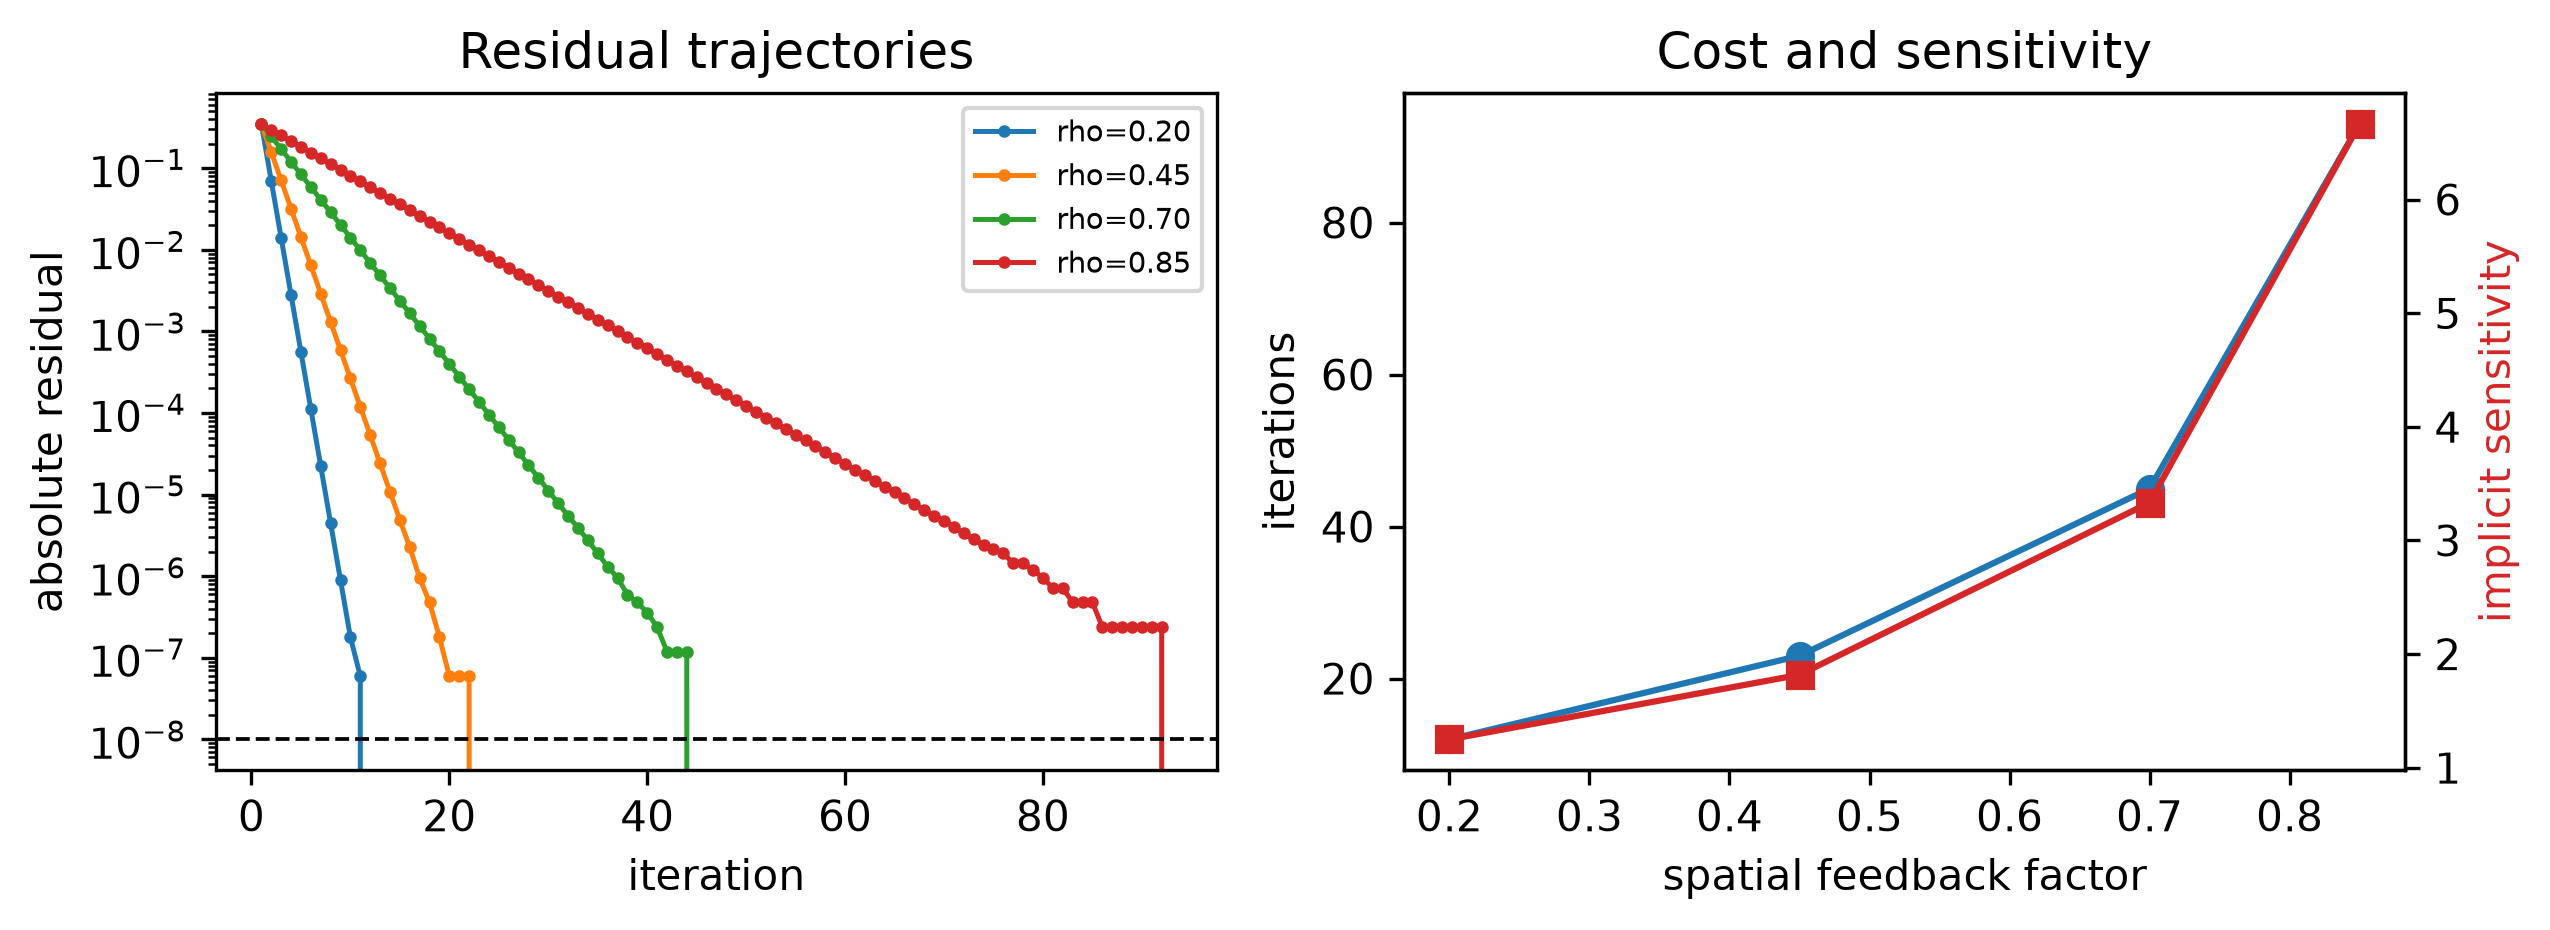

In [23]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('spatial feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the spatial feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | task error, per-scale residuals, and gradient agreement |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | channel/spatial shape at every scale and deterministic fusion |
| Scale sweep | Change one of image resolution, channels, scales, internal depth, and batch size at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| Where is every internal mapping derived? | [Point Architecture Catalog](https://jseluis.github.io/silva-networks/learn/point-architecture-catalog/) |
| Where are the factory modules checked as a script? | [Point Architecture Catalog Example](https://jseluis.github.io/silva-networks/examples/point-architecture-catalog/) |
| Which factory names and parameters are public? | [Point Architectures API](https://jseluis.github.io/silva-networks/api/point_architectures/) |
